# EDA

## Import

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import pandas as pd
import numpy as np

data_df = pd.read_parquet("data_clean.parquet")
feature_cols = data_df.select_dtypes(include=["float32"]).columns



#### Stylesheet

In [2]:
# --- Palette (dataviz-Skill, validiert für Farbfehlsichtigkeit) ---
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"]
)
DIVERGING_BLUE_RED = LinearSegmentedColormap.from_list(
    "div_blue_red", ["#184f95", "#f0efec", "#e34948"]
)
STATUS = {"good": "#0ca30c", "warning": "#fab219",
          "serious": "#ec835a", "critical": "#d03b3b"}

INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"


def set_plot_style():
    """Einmal pro Notebook aufrufen, gilt dann für alle folgenden Plots."""
    sns.set_theme(style="white")
    mpl.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": INK_MUTED,
        "axes.labelcolor": INK_SECONDARY,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 1,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "text.color": INK,
        "font.family": "sans-serif",
        "legend.frameon": False,
        "axes.prop_cycle": mpl.cycler(color=CATEGORICAL),
    })


set_plot_style()

#### Target-Balance

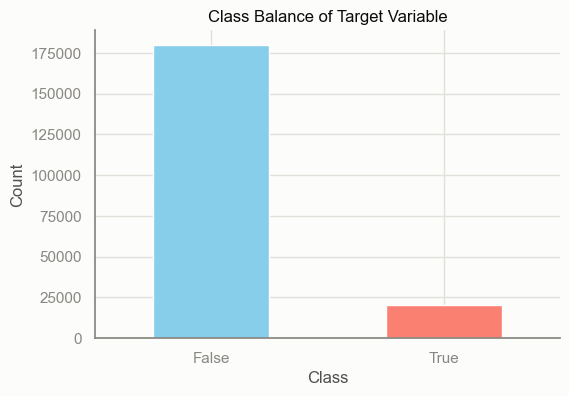

In [3]:
"""
Plots the class balance of the target variable in the given DataFrame.

Parameters:
data_df (pd.DataFrame): The input DataFrame containing the target variable.

Returns:
None
"""
# Count the occurrences of each class in the target variable
class_counts = data_df['target'].value_counts()

# Plotting
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Balance of Target Variable')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:
data_df.isna().sum().sum()

np.int64(0)

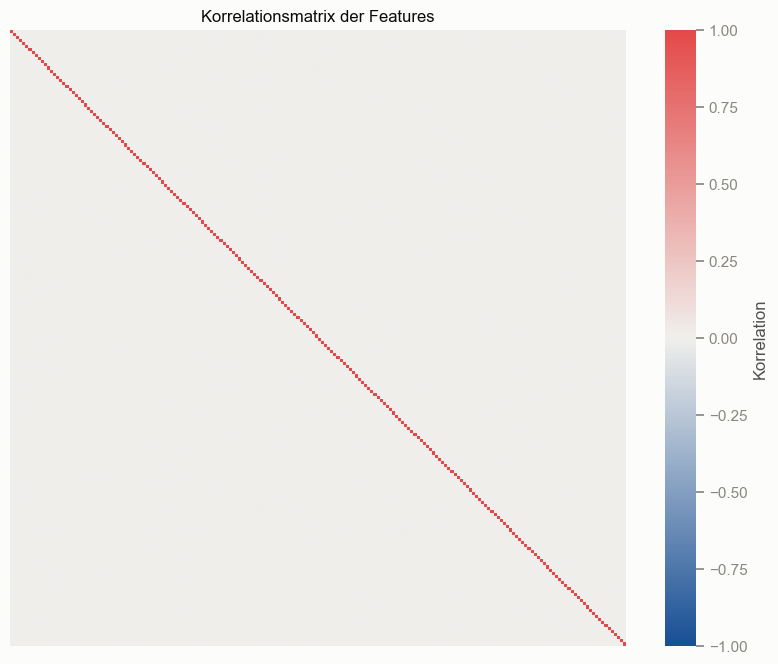

var_26   var_139   -0.009844
var_53   var_148   -0.009788
var_81   var_165    0.009714
         var_174    0.009490
var_183  var_189    0.009359
var_146  var_169    0.009071
var_6    var_80    -0.008958
var_122  var_132    0.008956
var_81   var_172    0.008936
var_1    var_80    -0.008855
dtype: float64

In [17]:
corr = data_df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap=DIVERGING_BLUE_RED,
    vmin=-1, vmax=1, center=0,
    square=True,
    xticklabels=False, yticklabels=False,  # 200 Labels wären unlesbar
    cbar_kws={"label": "Korrelation"},
)
plt.title("Korrelationsmatrix der Features")
plt.show()

# höchste Paare abseits der Diagonale, als Zahlen statt nur Heatmap
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
corr_pairs.head(10)


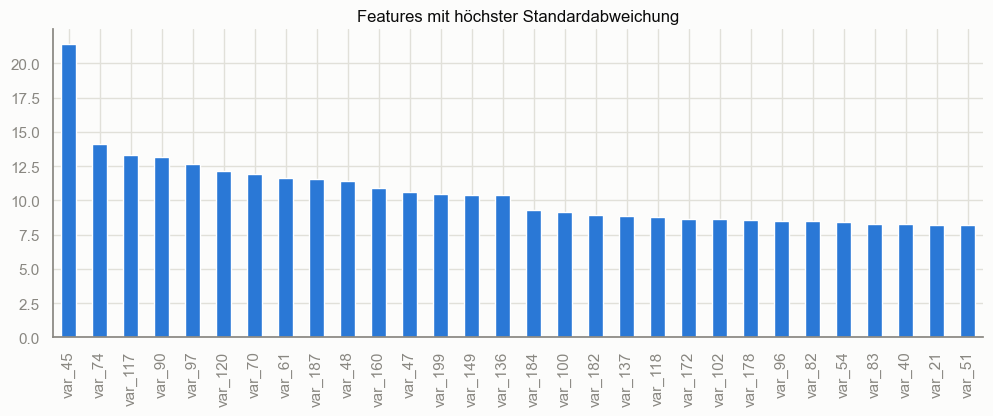

In [10]:
missing = data_df[feature_cols].std().sort_values(ascending=False).head(30).plot(
    kind="bar",
    figsize=(12, 4),
    title="Features mit höchster Standardabweichung"
)

<Axes: >

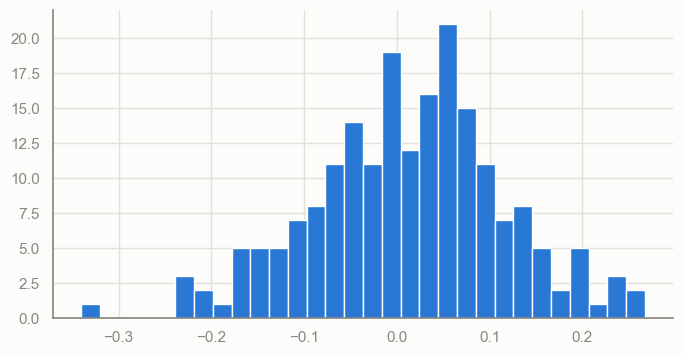

In [11]:
data_df[feature_cols].skew().hist(bins=30, figsize=(8, 4))

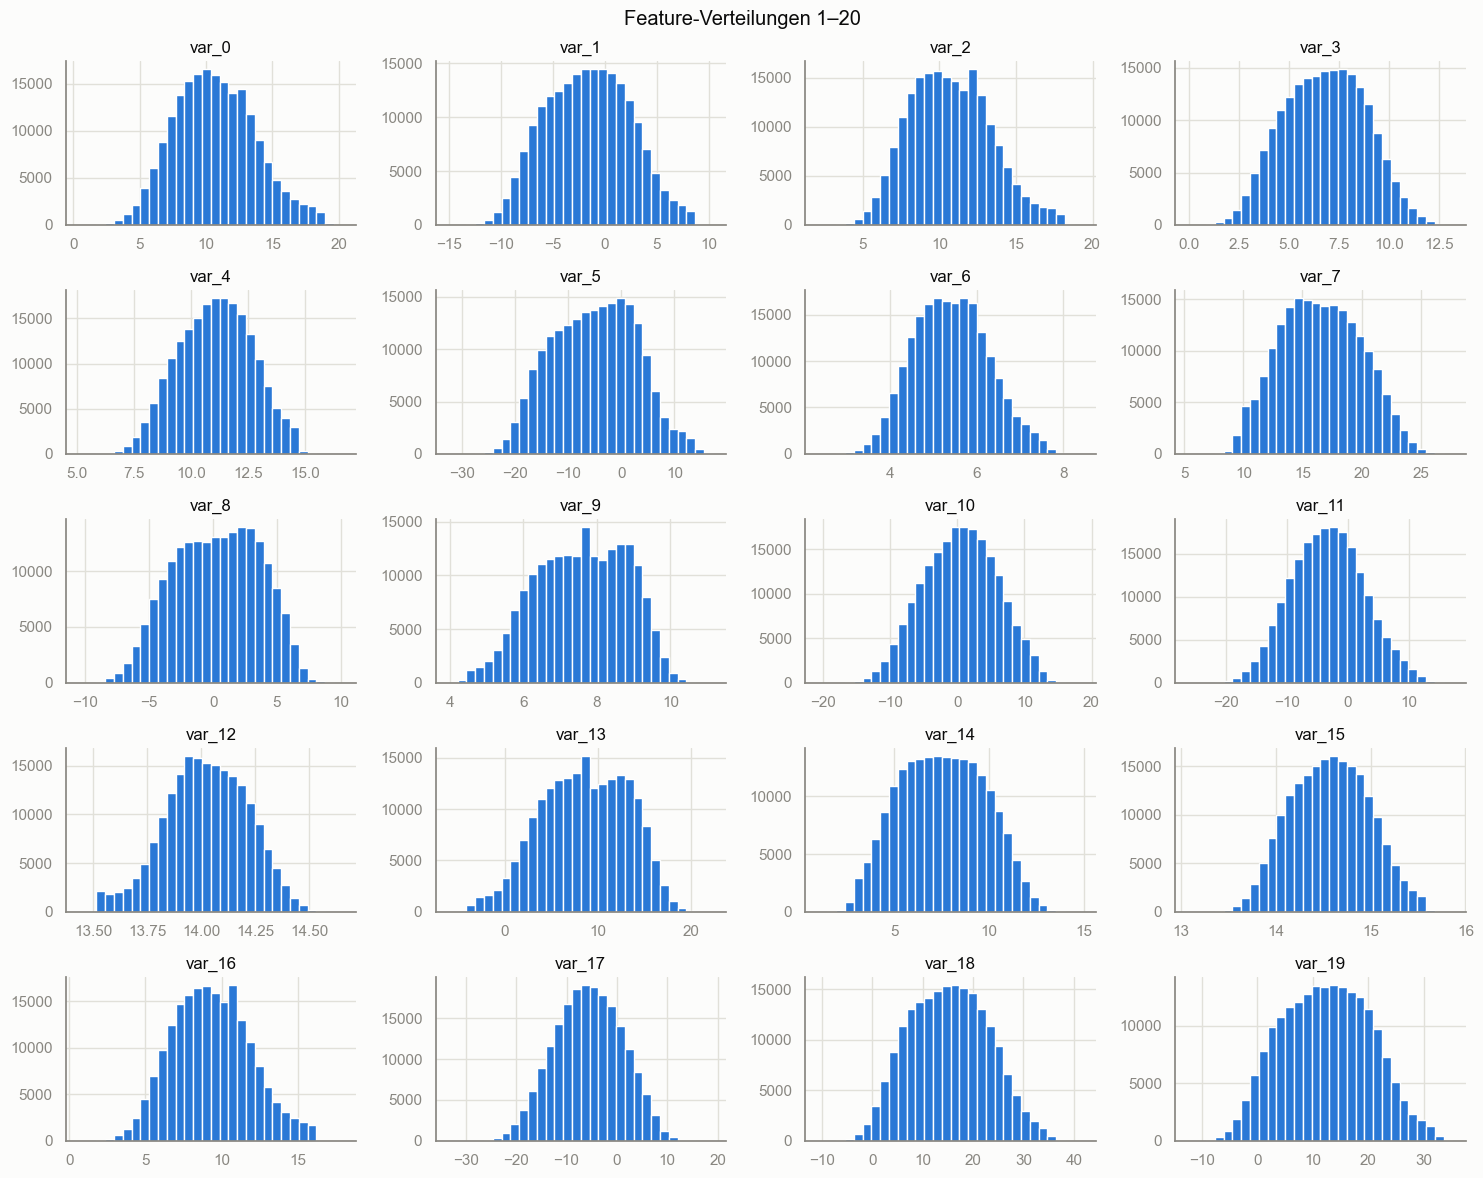

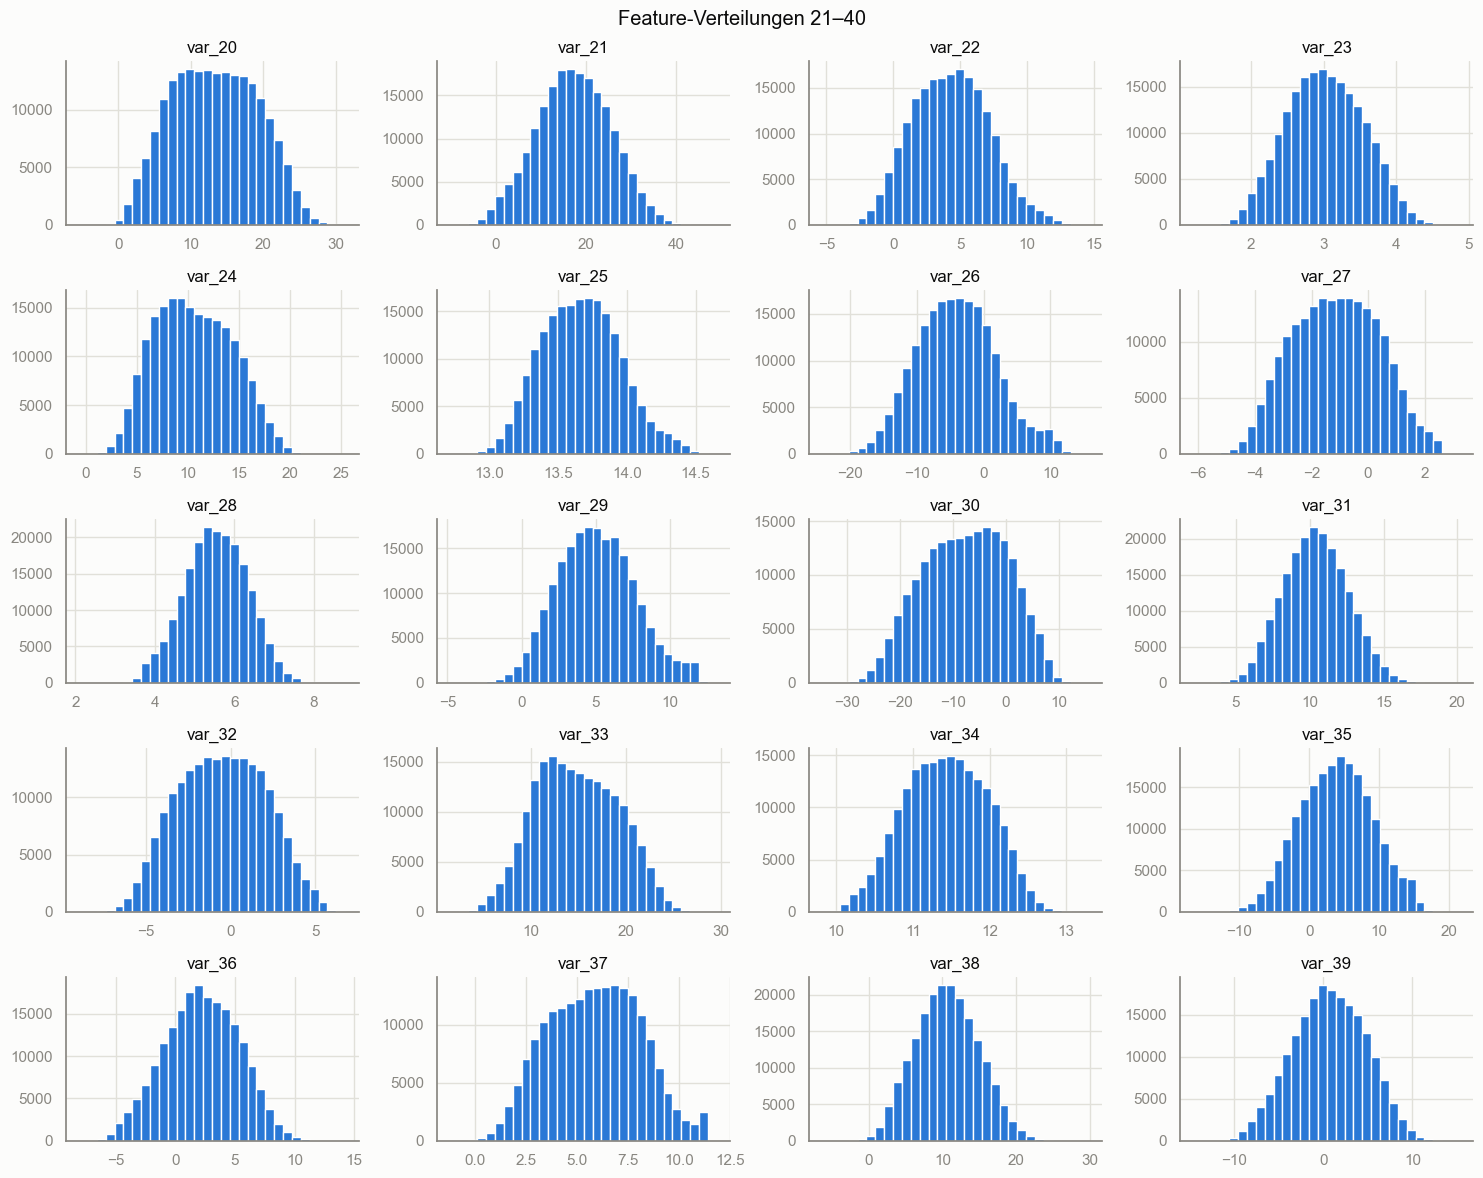

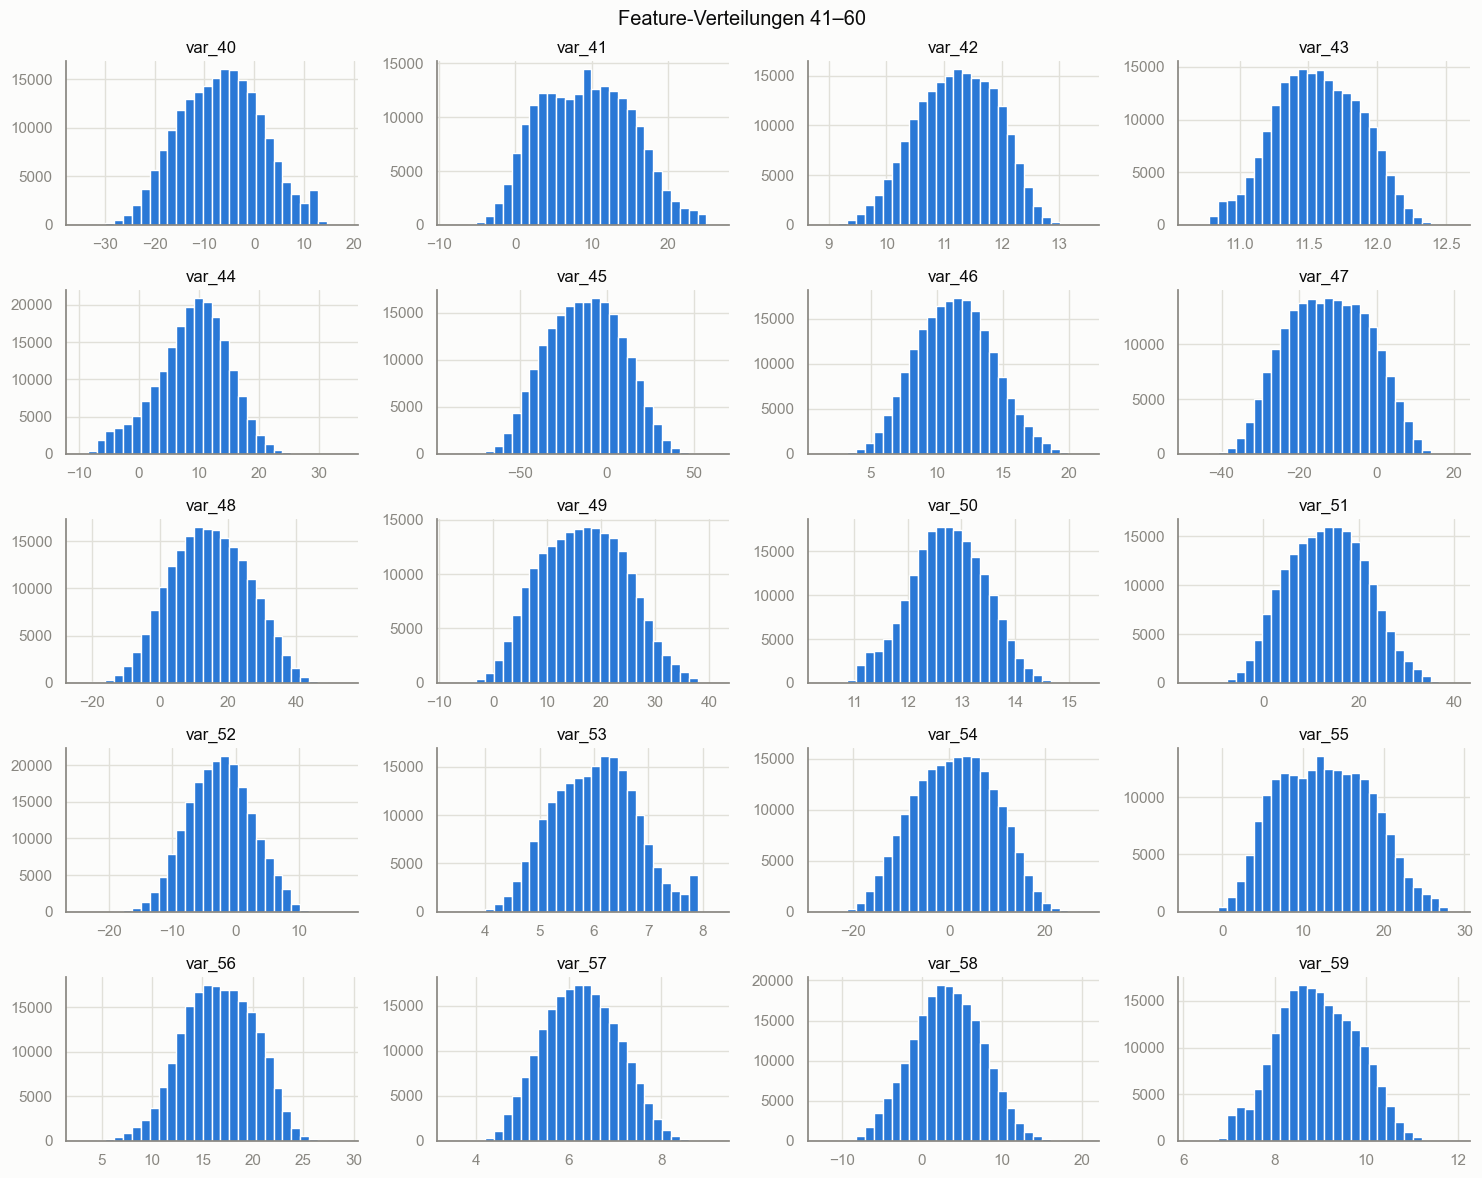

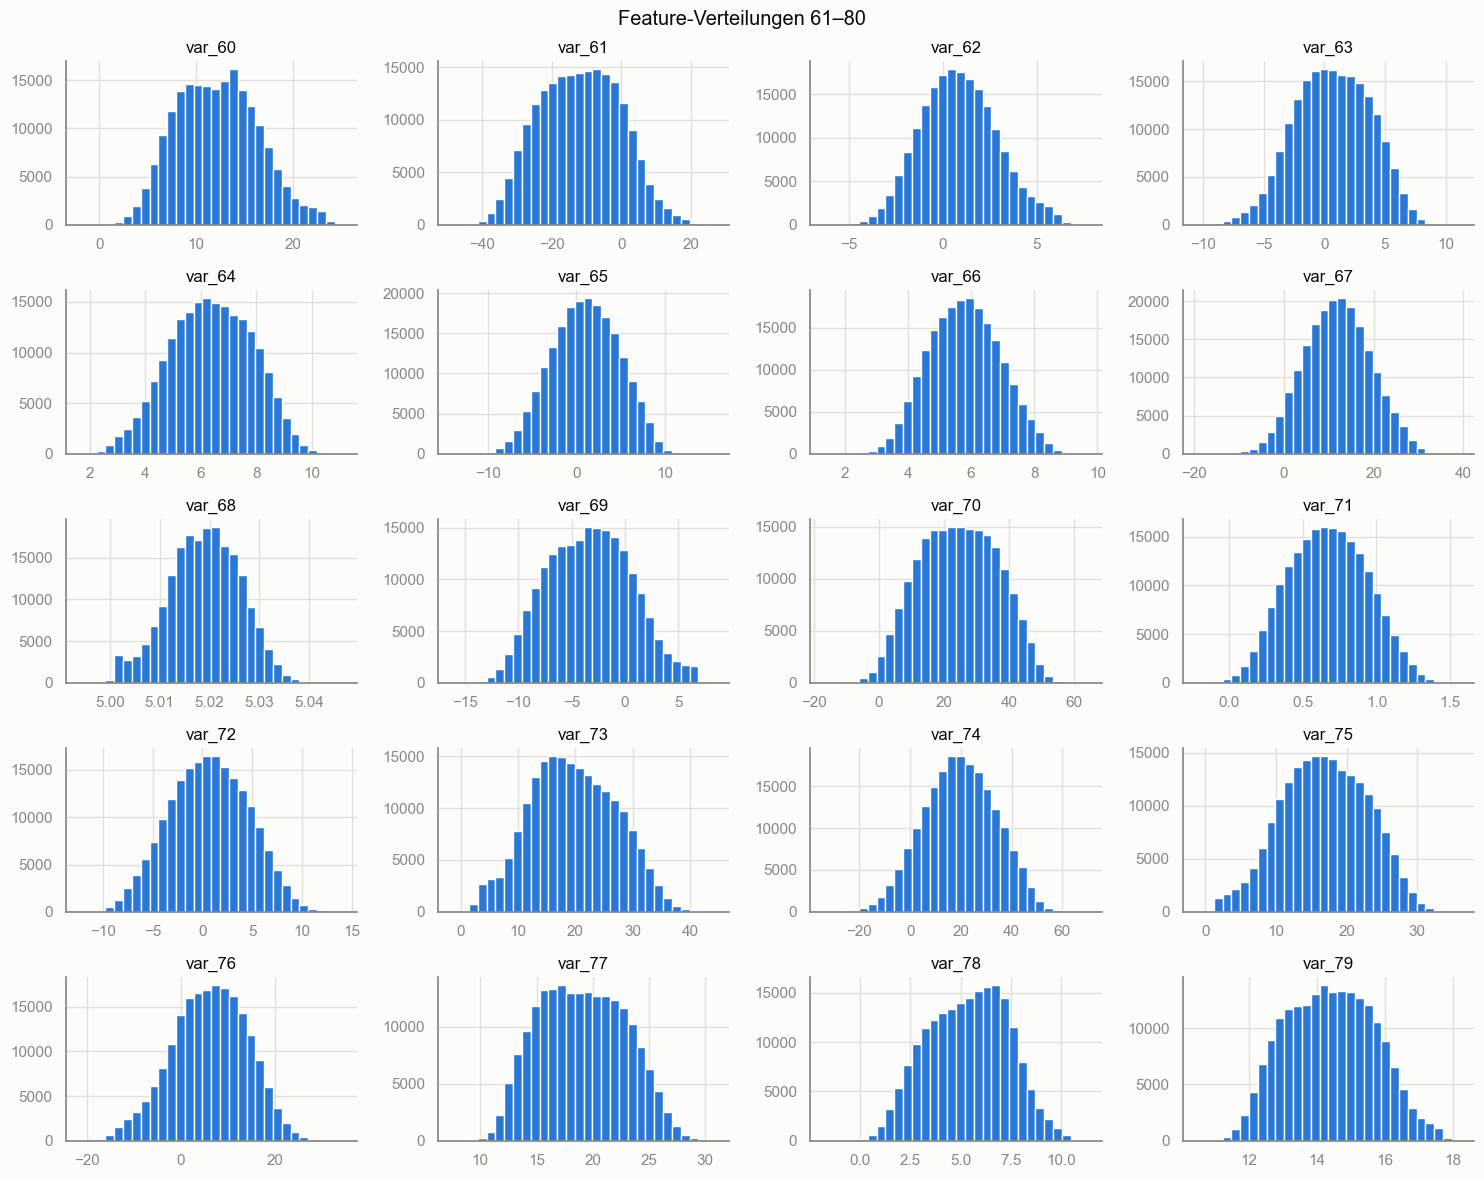

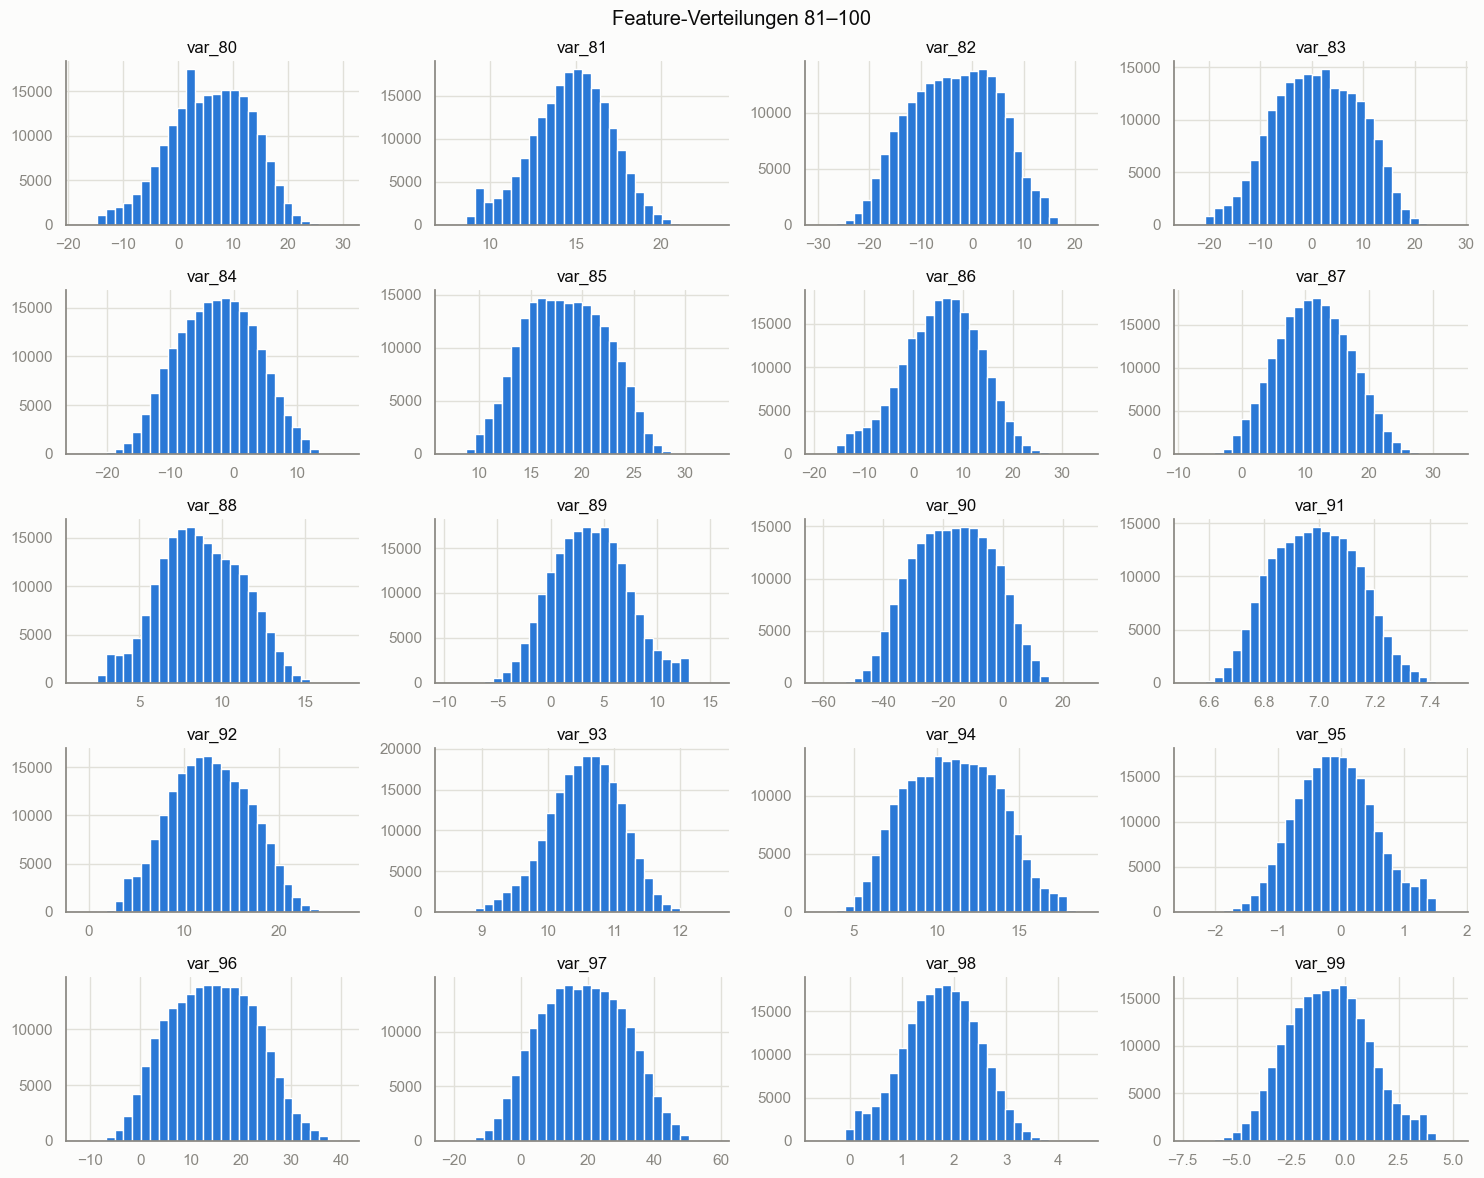

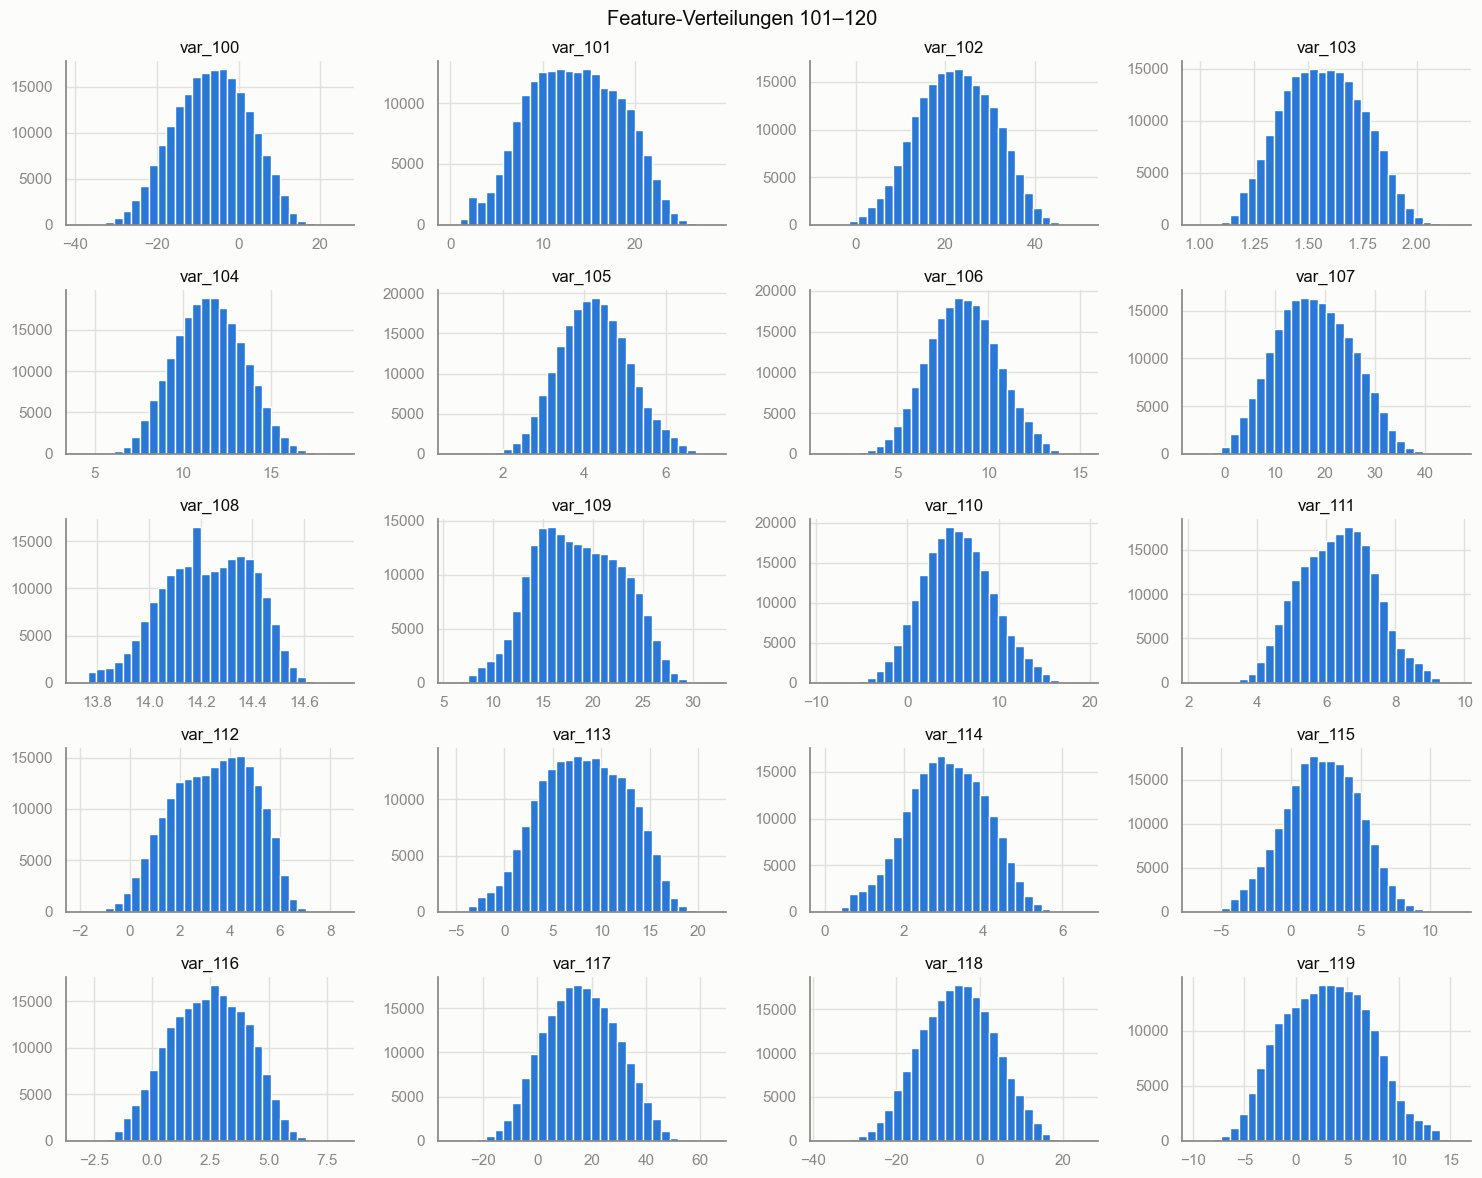

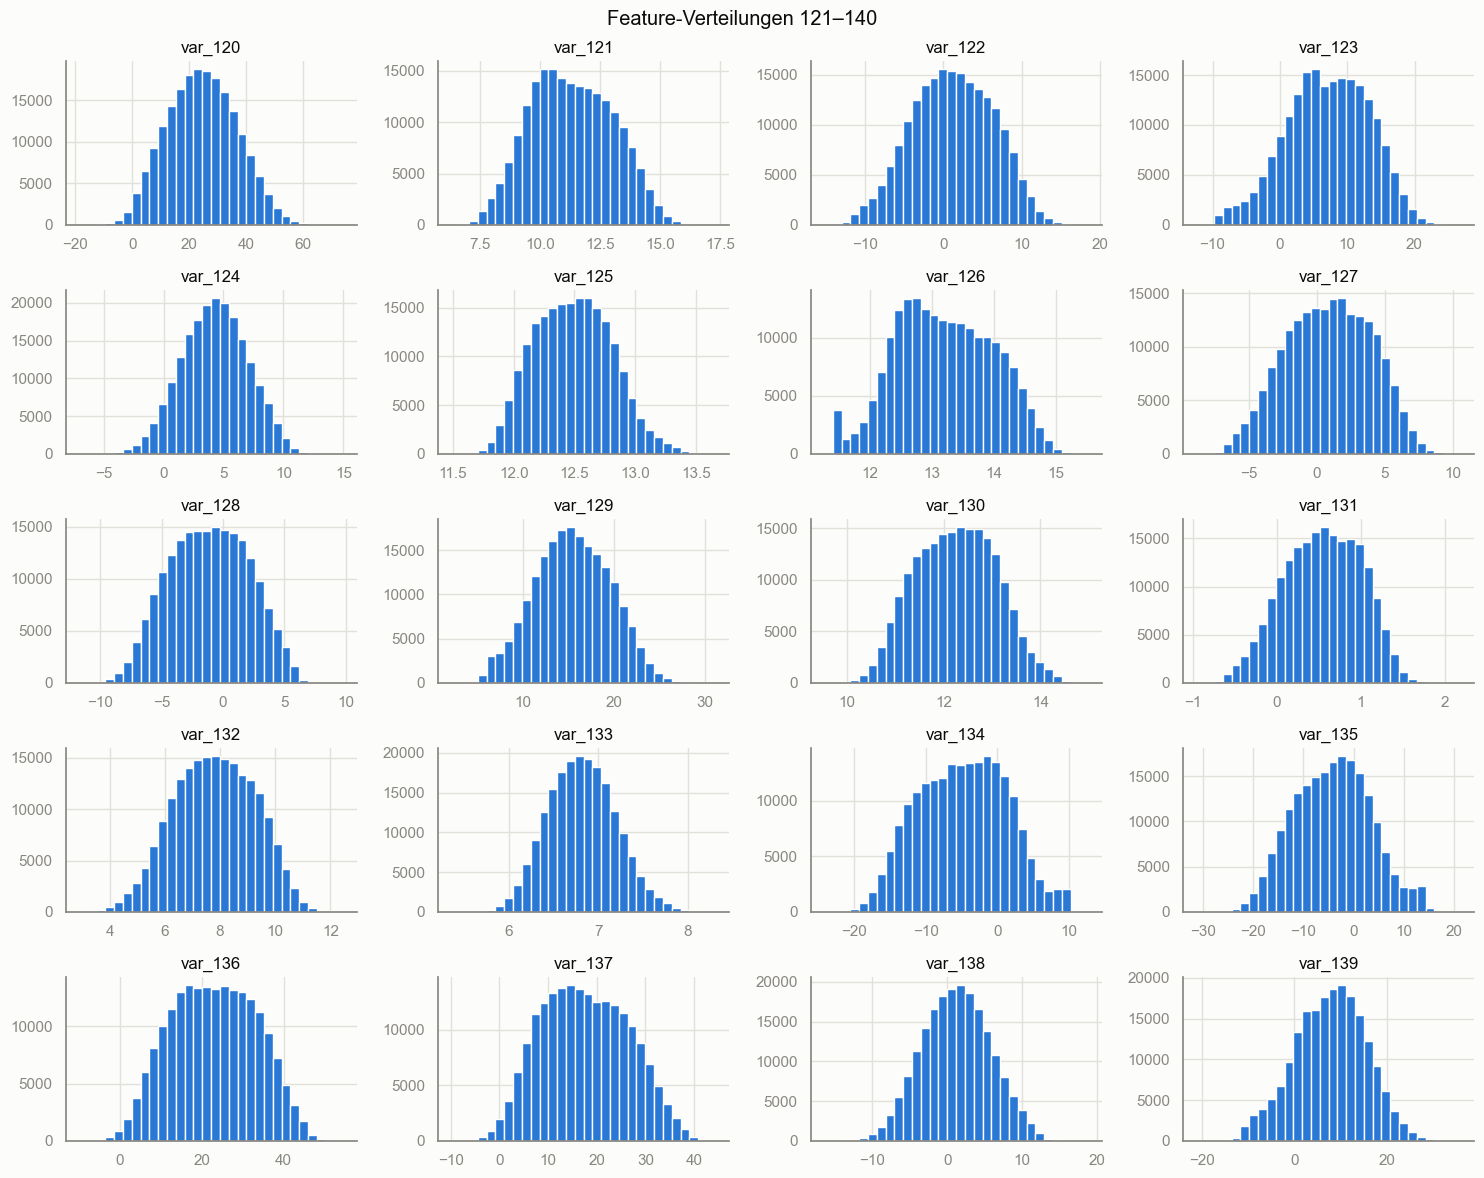

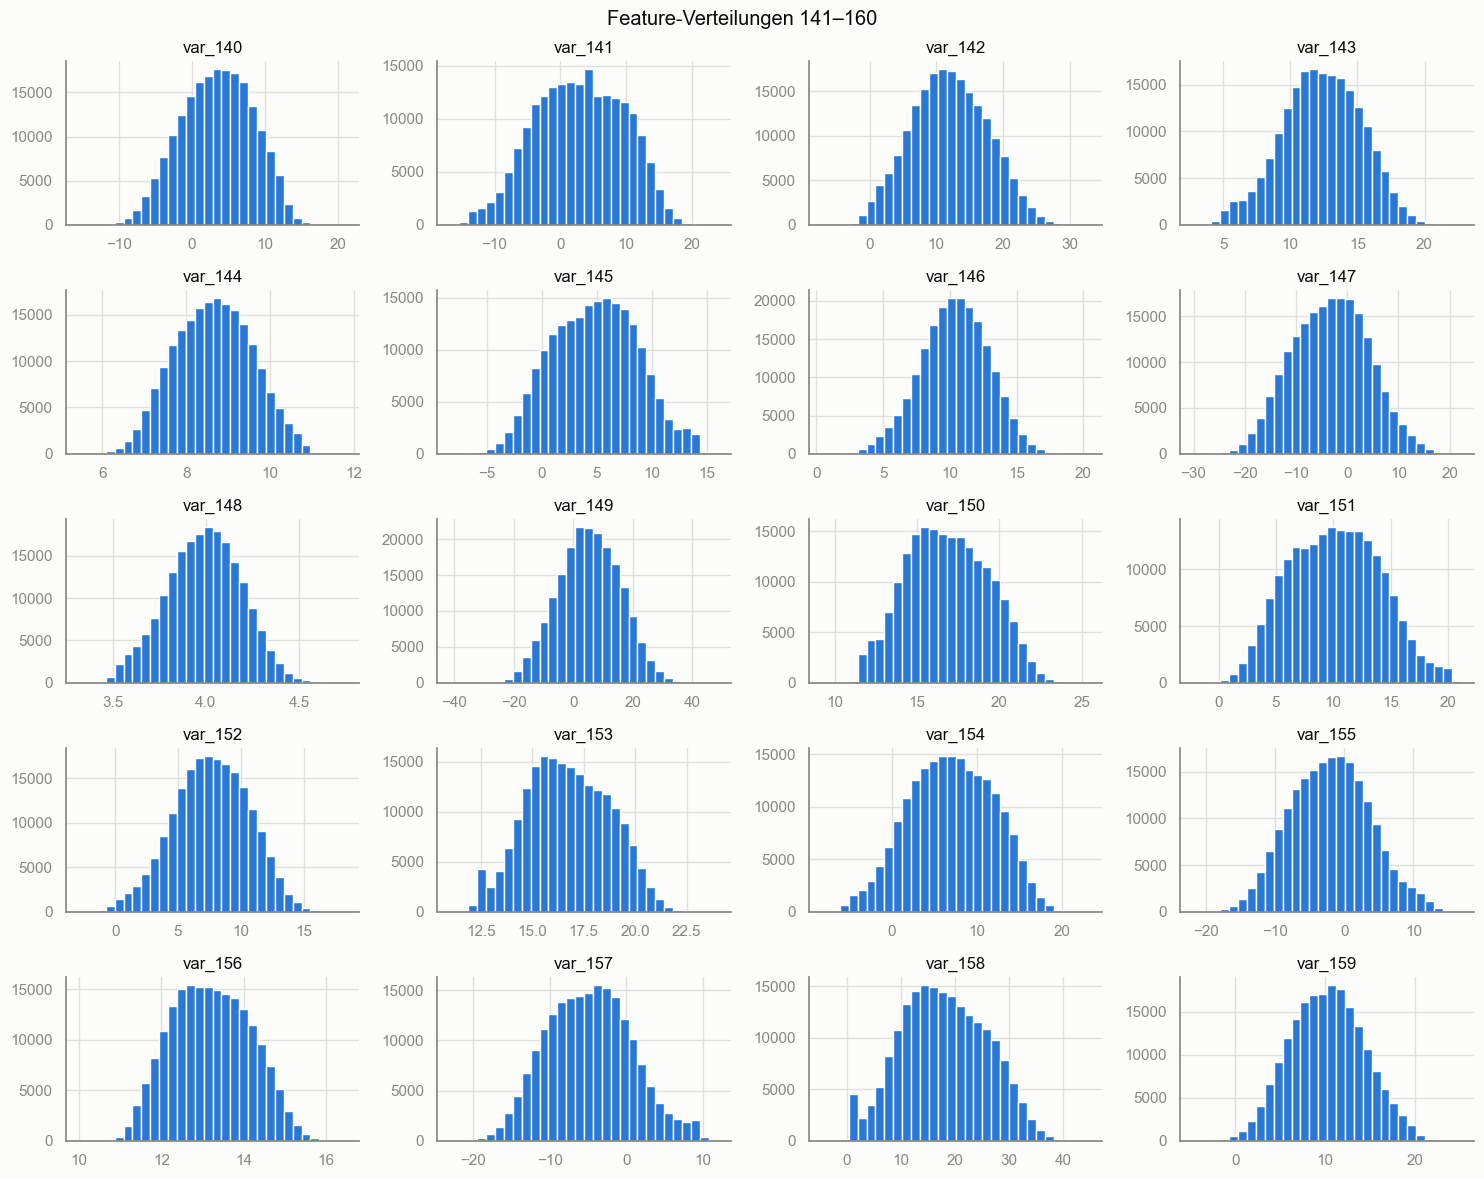

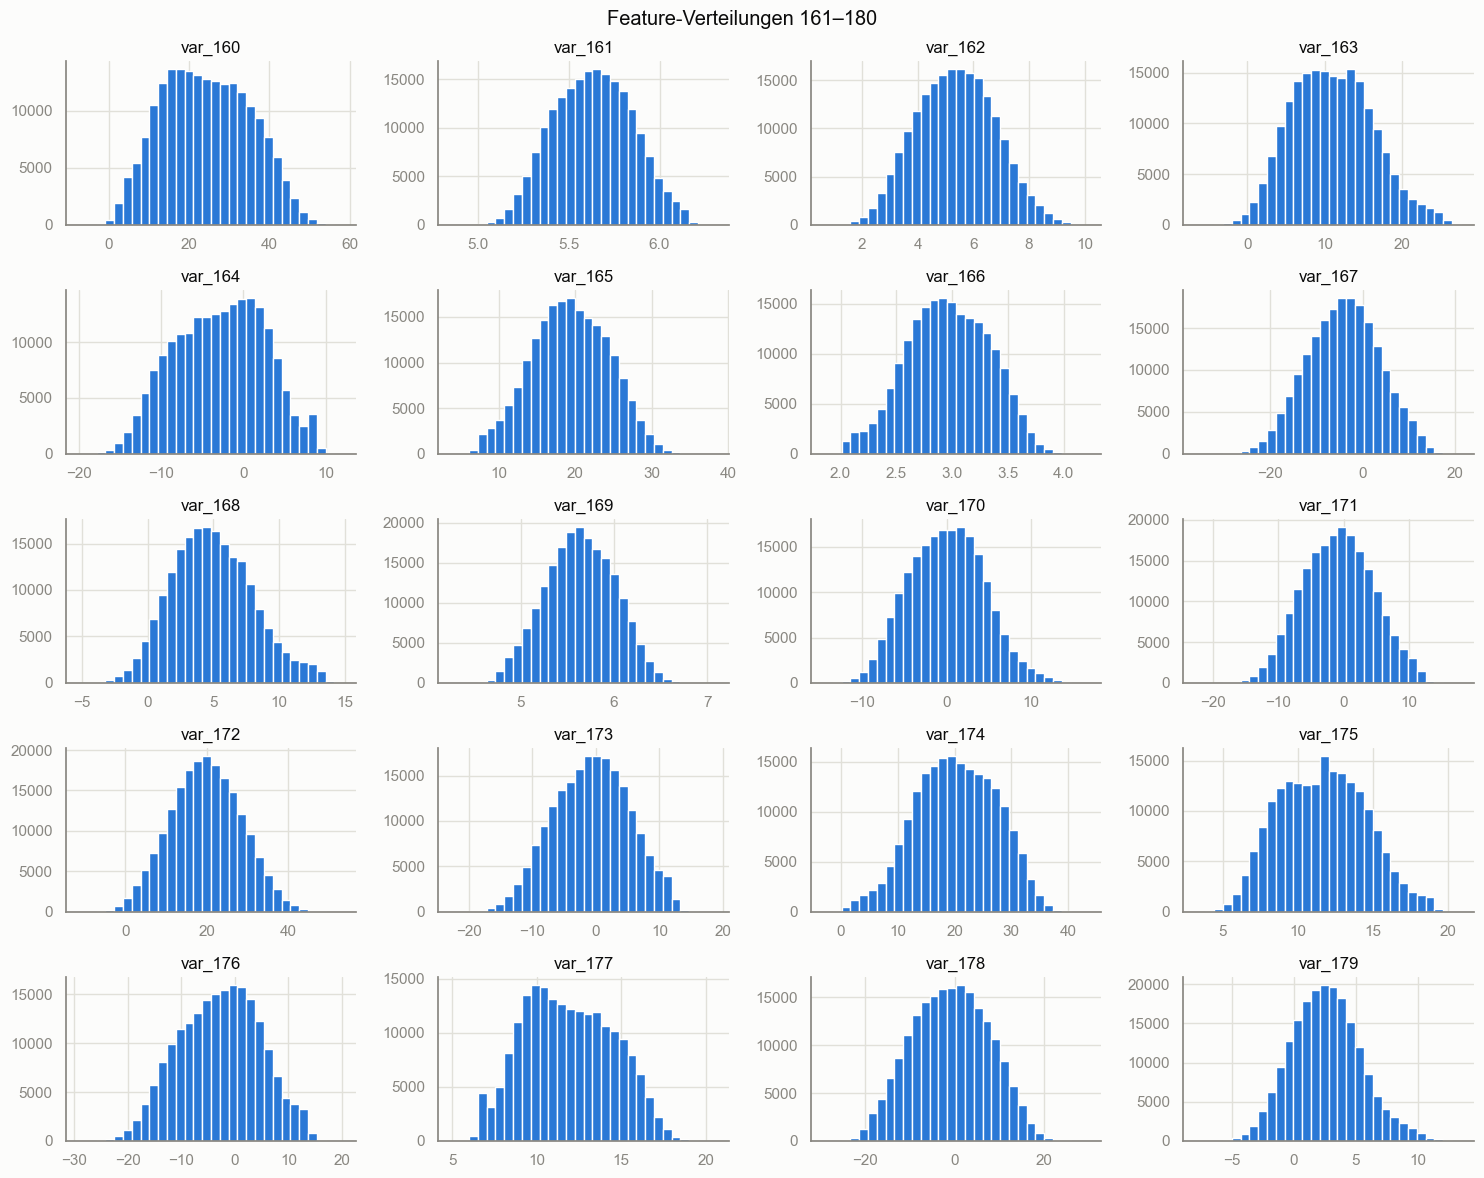

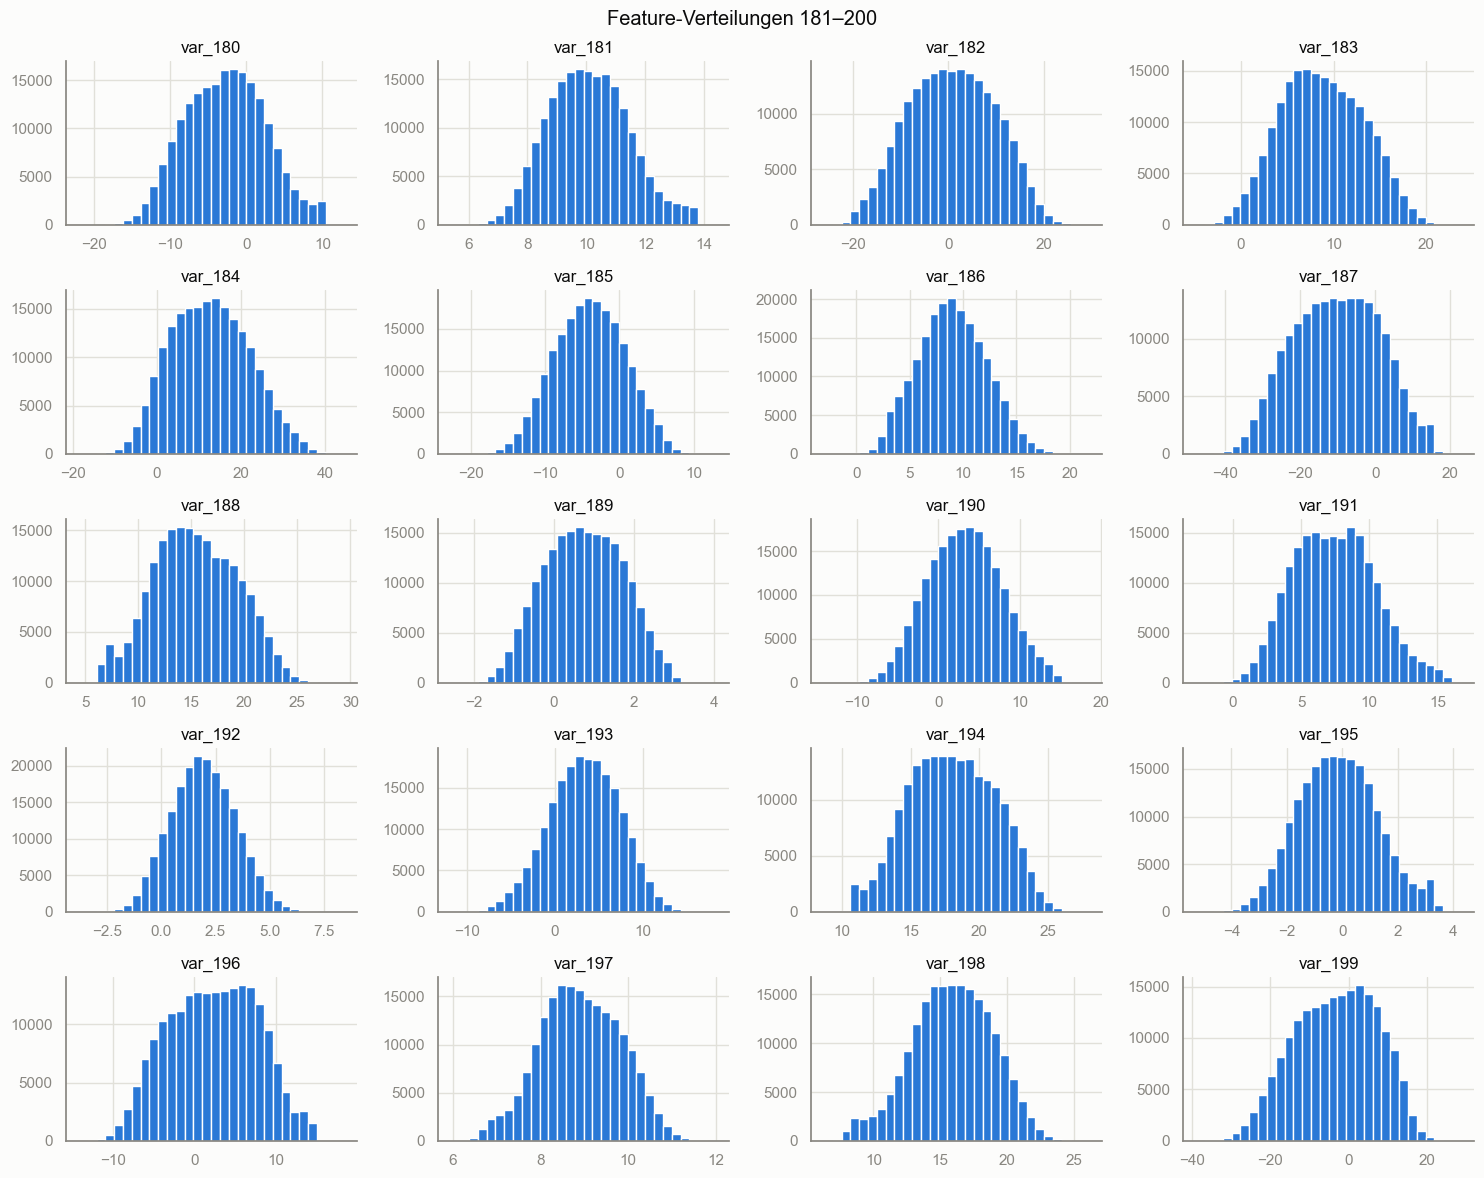

In [12]:
import matplotlib.pyplot as plt

features = data_df[feature_cols].columns
features_per_page = 20

for start in range(0, len(features), features_per_page):
    selected = features[start:start + features_per_page]

    data_df[feature_cols].loc[:, selected].hist(
        bins=30,
        figsize=(15, 12),
        layout=(5, 4)
    )

    plt.suptitle(
        f"Feature-Verteilungen {start + 1}–"
        f"{min(start + features_per_page, len(features))}"
    )
    plt.tight_layout()
    plt.show()